# 04. Findings

Four questions, answered with the tables built by `sql/duckdb/20-40`. Every number below is
recomputed from the database when this notebook runs.

In [1]:
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize

from denver311 import DUCKDB_PATH, PROCESSED_DIR, RAW_DIR
from denver311 import style
from denver311.style import NAVY, TEAL, BLUE, SLATE, LIGHT, INK

style.apply()
pd.set_option("display.max_columns", 40, "display.width", 160)
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
q = lambda sql: con.sql(sql).df()

In [2]:
from denver311 import EXPORT_DIR
kpi = pd.read_csv(EXPORT_DIR / "kpi_summary.csv")
kpi

,metric,value,unit,note
0,"Contacts, 2019-2025",3.010330e+06,count,Every row in the seven yearly files after clea...
1,"Field requests, 2019-2025",8.162660e+05,count,"Tied to a Denver place; not spam, duplicate, t..."
2,Field share of contacts,2.711550e-01,share,"Most 311 contacts are questions, not field work."
3,Closed within 15 minutes,6.085924e-01,share,Contacts closed within 15 minutes of creation.
4,"Like-for-like field requests, 2019 to 2025",5.054345e-02,change,"Excludes solid-waste types, which leave the 31..."
5,"App share of field requests, 2019",2.286136e-01,share,PocketGov share of field requests.
6,"App share of field requests, 2022 peak",4.814673e-01,share,PocketGov share of field requests.
7,"App share of field requests, 2025",2.574714e-01,share,PocketGov share of field requests.
8,Request types slower to close via app,1.400000e+01,count,Out of 14 types with 500+ closed requests on b...
9,Type-years with a record gap,1.300000e+01,count,Out of 175; over 20% never closed or over 25% ...


## Speed: which request types carry the longest tails?

Top 25 field request types present in all seven years. No official service-level target is in
the data, so each type is benchmarked against **its own 2019 P90** (the time by which 90% of its
2019 requests were closed). That benchmark is derived, not a city standard.

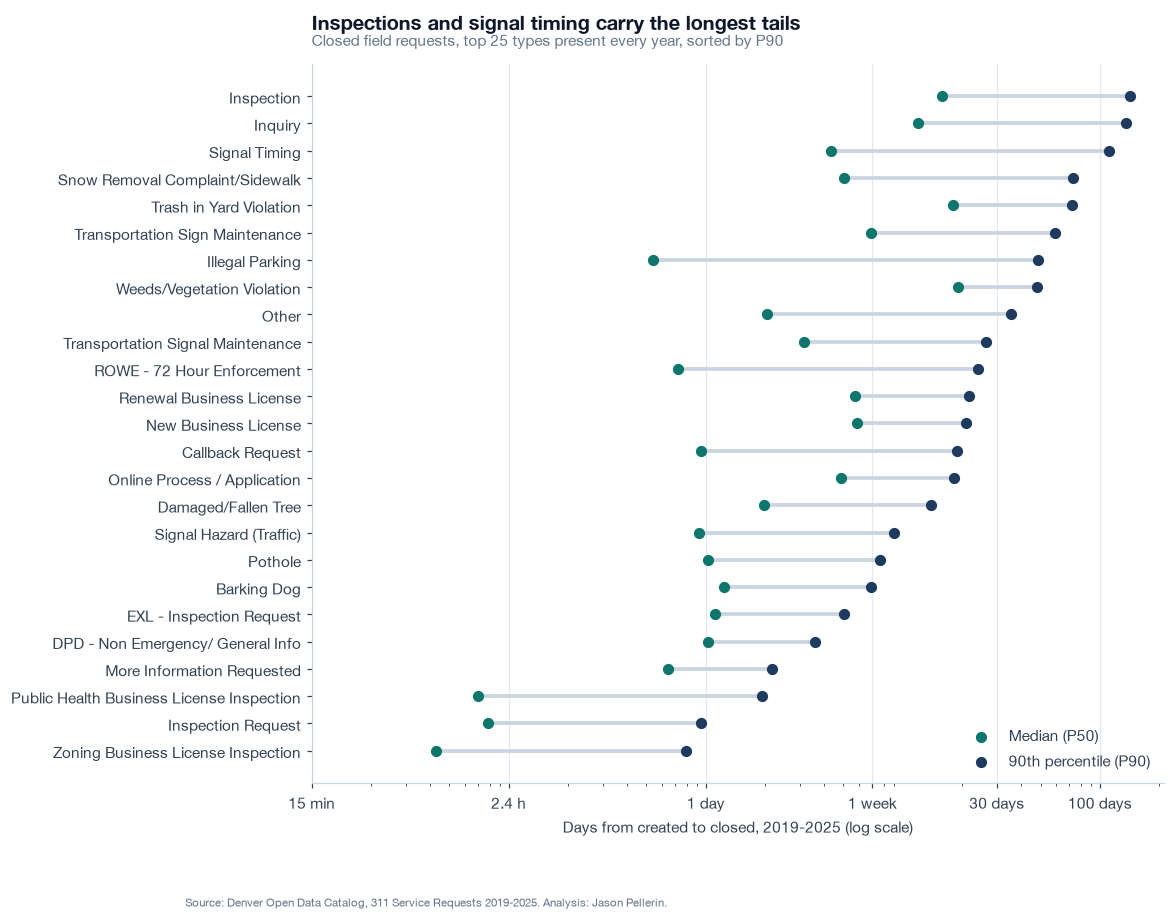

In [3]:
t = q("SELECT * FROM agg_type_summary ORDER BY p90_days")
fig, ax = plt.subplots(figsize=(10, 8.5))
ypos = np.arange(len(t))
ax.hlines(ypos, t.p50_days.clip(lower=0.01), t.p90_days, color=LIGHT, lw=2.5)
ax.scatter(t.p50_days.clip(lower=0.01), ypos, color=TEAL, s=40, zorder=3, label="Median (P50)")
ax.scatter(t.p90_days, ypos, color=NAVY, s=40, zorder=3, label="90th percentile (P90)")
ax.set_yticks(ypos, t.request_type)
ax.set_xscale("log")
ax.set_xticks([0.01, 0.1, 1, 7, 30, 100], ["15 min", "2.4 h", "1 day", "1 week", "30 days", "100 days"])
ax.set_xlabel("Days from created to closed, 2019-2025 (log scale)")
ax.set_title("Inspections and signal timing carry the longest tails", pad=22)
style.subtitle(ax, "Closed field requests, top 25 types present every year, sorted by P90")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
style.save(fig, "fig06_type_speed");

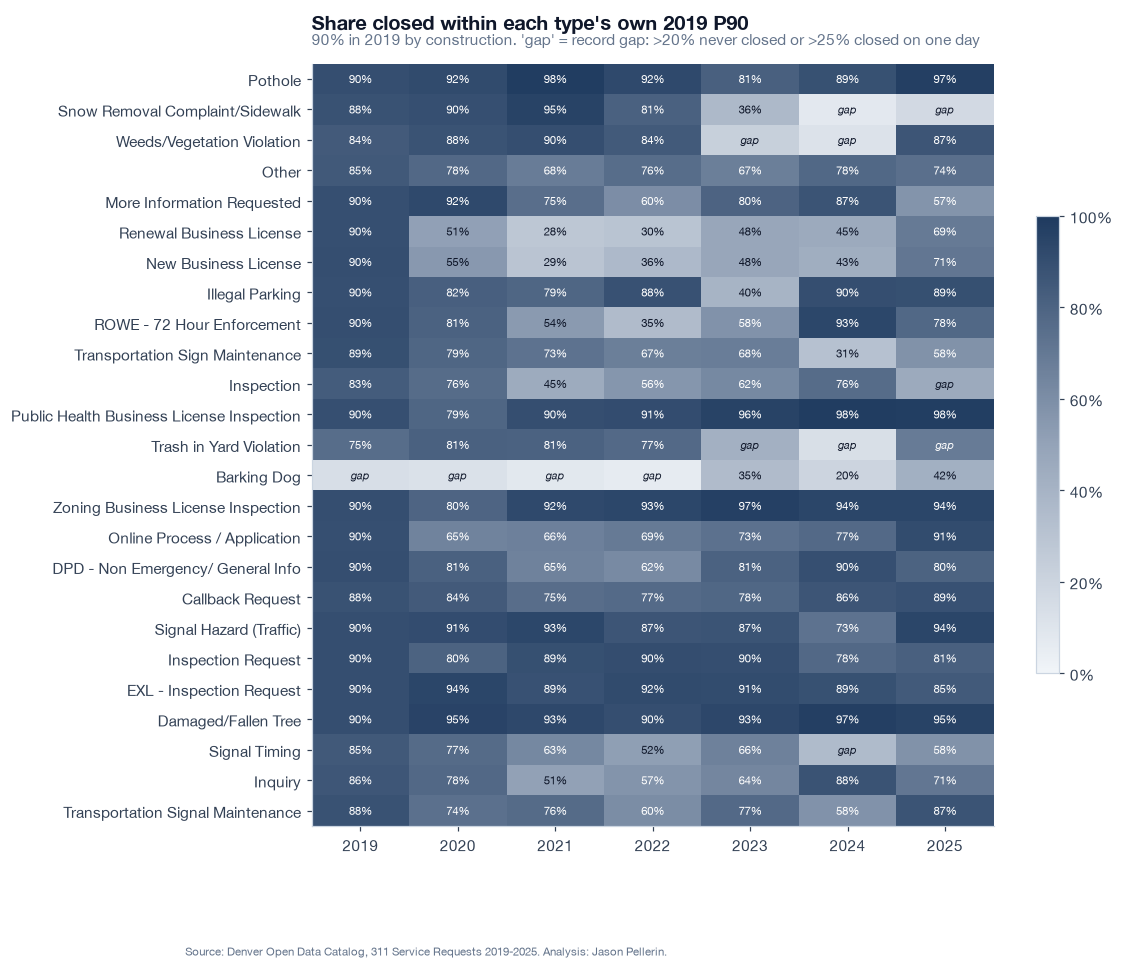

In [4]:
ty = q("SELECT request_type, year, share_within_2019_p90, record_gap, requests_total FROM agg_type_year")
order = ty.groupby("request_type").requests_total.first().sort_values(ascending=False).index
share = ty.pivot(index="request_type", columns="year", values="share_within_2019_p90").loc[order]
gap = ty.pivot(index="request_type", columns="year", values="record_gap").loc[order]
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(share.values, cmap=style.SEQUENTIAL, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(7), share.columns)
ax.set_yticks(range(len(order)), order)
for i in range(share.shape[0]):
    for j in range(7):
        v = share.values[i, j]
        label = "gap" if gap.values[i, j] else f"{v:.0%}"
        ax.text(j, i, label, ha="center", va="center", fontsize=7.5,
                color="white" if v > 0.55 else INK, fontstyle="italic" if gap.values[i, j] else "normal")
ax.grid(False)
ax.set_title("Share closed within each type's own 2019 P90", pad=22)
style.subtitle(ax, "90% in 2019 by construction. 'gap' = record gap: >20% never closed or >25% closed on one day")
fig.colorbar(im, ax=ax, shrink=0.6, format=lambda x, _: f"{x:.0%}")
style.save(fig, "fig07_benchmark_heatmap");

In [5]:
q('''
SELECT request_type, year, requests, round(p50_hours / 24, 1) AS p50_days, round(p90_hours / 24, 1) AS p90_days, record_gap
FROM agg_type_year WHERE request_type IN ('New Business License', 'Renewal Business License', 'Pothole') ORDER BY 1, 2
''')

,request_type,year,requests,p50_days,p90_days,record_gap
0,New Business License,2019,149,1.0,5.2,False
1,New Business License,2020,1247,4.0,26.2,False
2,New Business License,2021,1154,8.4,21.9,False
3,New Business License,2022,1198,7.1,22.2,False
4,New Business License,2023,1900,5.7,20.7,False
5,New Business License,2024,1648,6.0,20.8,False
6,New Business License,2025,946,3.9,8.8,False
7,Pothole,2019,3667,1.8,8.1,False
8,Pothole,2020,5180,0.6,6.9,False
9,Pothole,2021,4158,0.7,4.1,False


Two real speed stories, with complete records behind them:

- **Business licenses slowed and recovered.** New Business License requests went from a 1-day
  median in 2019 to 8.4 days in 2021, and were back to 3.9 days (P90 8.8 days) in 2025.
- **Potholes are the most consistent service in the file.** The median sits between about half a
  day and 2.5 days in every year, and 81-98% close inside the 2019 benchmark.

## Against the city's own goals

DOTI publishes Level of Service goals in business days for its common request types
(denvergov.org, retrieved 2026-09-29). Five of the top 25 types have one. The goals are current,
so earlier years are a retrospective comparison. Open cases count as misses.

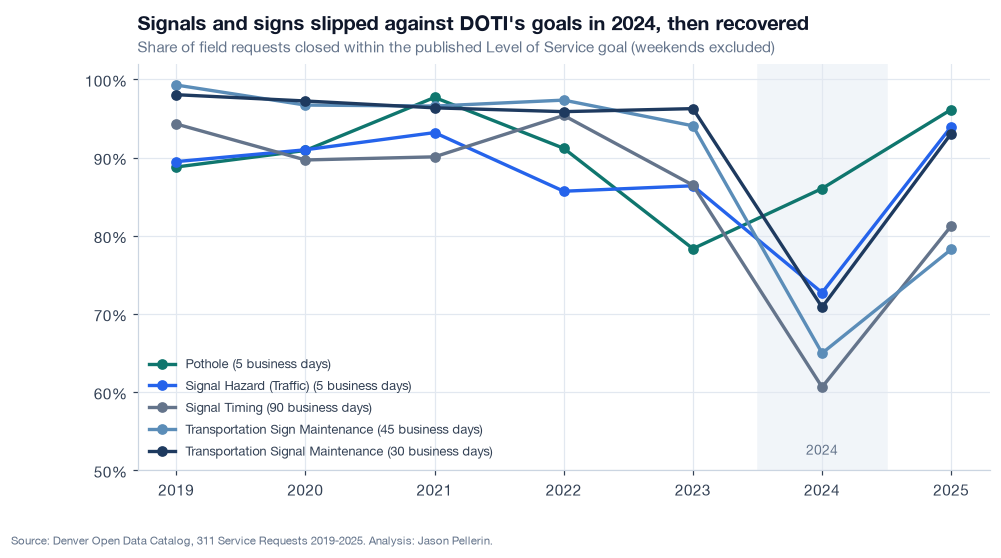

In [6]:
los = q("SELECT * FROM agg_published_los")
los["label"] = los.request_type + " (" + los.los_business_days.astype(str) + " business days)"
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = dict(zip(sorted(los.label.unique()), [TEAL, BLUE, SLATE, "#5b8db8", NAVY]))
for label, grp in los.groupby("label"):
    ax.plot(grp.year, grp.share_within_los, marker="o", lw=2.2, color=colors[label], label=label)
ax.axvspan(2023.5, 2024.5, color="#f1f5f9", zorder=0)
ax.text(2024, 0.52, "2024", ha="center", color=SLATE, fontsize=9)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_ylim(0.5, 1.02)
ax.set_title("Signals and signs slipped against DOTI's goals in 2024, then recovered", pad=22)
style.subtitle(ax, "Share of field requests closed within the published Level of Service goal (weekends excluded)")
ax.legend(loc="lower left", fontsize=8.5)
style.save(fig, "fig14_published_los");

Potholes meet the 5-business-day goal in 78-98% of cases every year; their weakest year was 2023.
The four signal and sign types held 86-99% through 2023, fell to 61-73% in 2024, and recovered in
2025. The derived 2019 benchmark shows the same 2024 dip, which is a useful check on the derived
method.

## The record gap in code enforcement

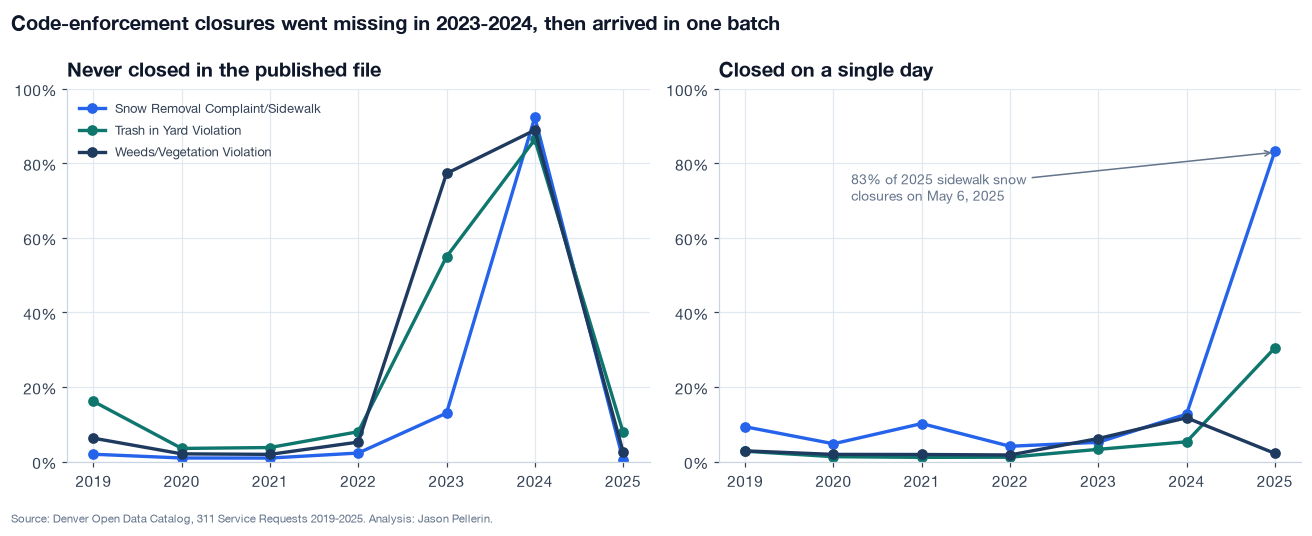

In [7]:
ci = q('''
SELECT request_type, year, open_in_file_share, top_close_day_share FROM agg_closure_integrity
WHERE request_type IN ('Weeds/Vegetation Violation', 'Snow Removal Complaint/Sidewalk', 'Trash in Yard Violation')
''')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
for (t, grp), color in zip(ci.groupby("request_type"), [BLUE, TEAL, NAVY]):
    axes[0].plot(grp.year, grp.open_in_file_share, marker="o", lw=2.2, color=color, label=t)
    axes[1].plot(grp.year, grp.top_close_day_share, marker="o", lw=2.2, color=color, label=t)
axes[0].set_title("Never closed in the published file", pad=8)
axes[1].set_title("Closed on a single day", pad=8)
for ax in axes:
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.set_ylim(0, 1)
axes[0].legend(loc="upper left", fontsize=8.5)
axes[1].annotate("83% of 2025 sidewalk snow\nclosures on May 6, 2025", xy=(2025, 0.83), xytext=(2020.2, 0.7),
                 fontsize=9, color=SLATE, arrowprops=dict(arrowstyle="->", color=SLATE))
fig.suptitle("Code-enforcement closures went missing in 2023-2024, then arrived in one batch", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
style.save(fig, "fig08_record_gap");

This is the most important finding for anyone who would build a dashboard on this data. In
2023 and 2024, 77-92% of weed, sidewalk snow, and trash-in-yard cases stayed at `Routed to
Agency` and never received a close timestamp. A naive time-to-close chart shows those years as
fast (only the few cases that did close are measured) or slow (if open cases count as misses).
Neither is true. The data cannot say whether the work happened; it can only say the record
was not closed back in 311.

## Channel: phone, app, and what could be self-service

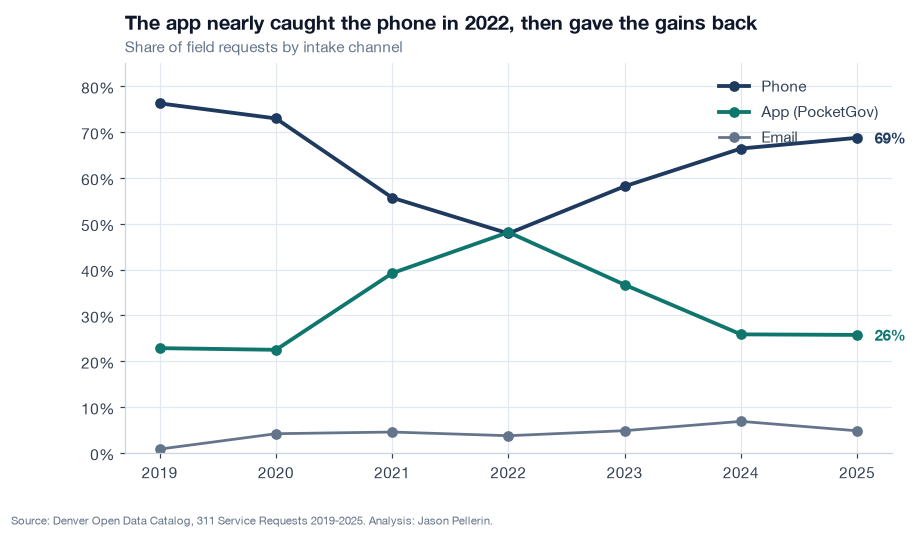

In [8]:
c = q("SELECT year, channel, share_of_field FROM agg_channel_year").pivot(index="year", columns="channel", values="share_of_field")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(c.index, c["Phone"], color=NAVY, lw=2.5, marker="o", label="Phone")
ax.plot(c.index, c["App (PocketGov)"], color=TEAL, lw=2.5, marker="o", label="App (PocketGov)")
ax.plot(c.index, c["Email"], color=SLATE, lw=1.8, marker="o", label="Email")
for col, color in [("Phone", NAVY), ("App (PocketGov)", TEAL)]:
    ax.text(2025.15, c[col].iloc[-1], f"{c[col].iloc[-1]:.0%}", color=color, va="center", fontweight="bold")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_ylim(0, 0.85)
ax.set_title("The app nearly caught the phone in 2022, then gave the gains back", pad=22)
style.subtitle(ax, "Share of field requests by intake channel")
ax.legend(loc="upper right")
style.save(fig, "fig09_channel_share");

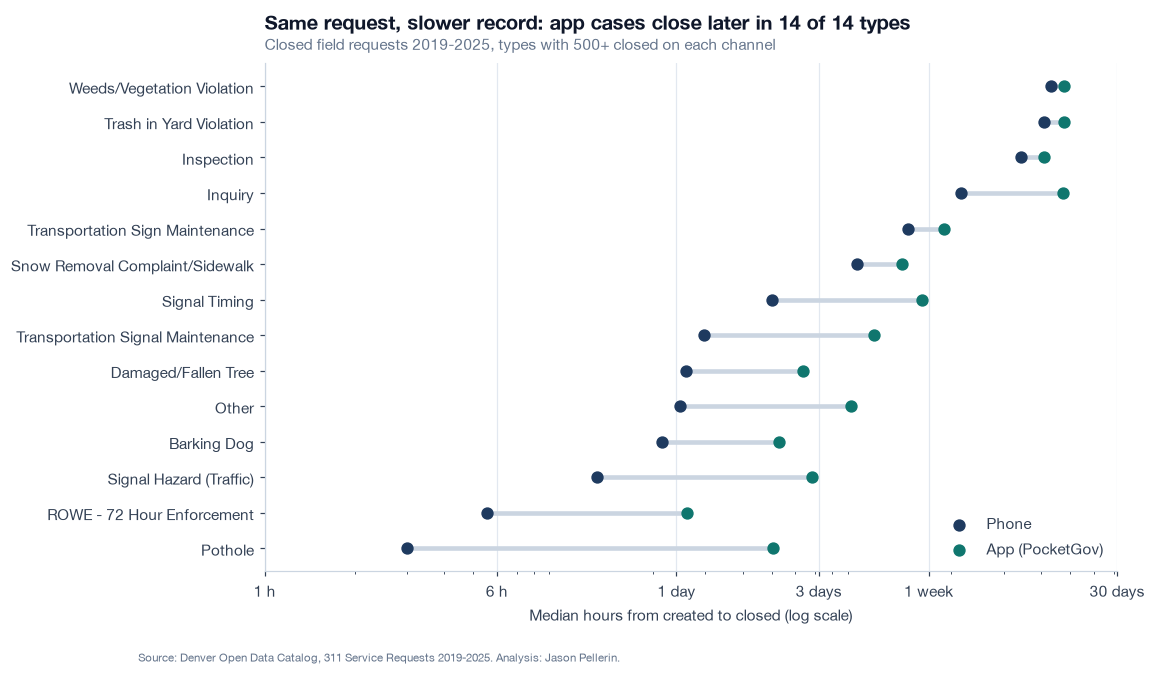

In [9]:
cs = q("SELECT * FROM agg_channel_speed ORDER BY phone_p50_hours")
fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(cs))
ax.hlines(ypos, cs.phone_p50_hours, cs.app_p50_hours, color=LIGHT, lw=3)
ax.scatter(cs.phone_p50_hours, ypos, color=NAVY, s=50, zorder=3, label="Phone")
ax.scatter(cs.app_p50_hours, ypos, color=TEAL, s=50, zorder=3, label="App (PocketGov)")
ax.set_yticks(ypos, cs.request_type)
ax.set_xscale("log")
ax.set_xticks([1, 6, 24, 72, 168, 720], ["1 h", "6 h", "1 day", "3 days", "1 week", "30 days"])
ax.set_xlabel("Median hours from created to closed (log scale)")
ax.set_title(f"Same request, slower record: app cases close later in {(cs.app_minus_phone_hours > 0).sum()} of {len(cs)} types", pad=22)
style.subtitle(ax, "Closed field requests 2019-2025, types with 500+ closed on each channel")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
style.save(fig, "fig10_channel_speed");

Potholes are the sharpest example: a 3-hour median when reported by phone and a 50-hour median
through the app. The data cannot separate the causes (a phone agent can route and close in one
step; an app submission may wait in a queue for triage), but the gap is consistent across every
type with enough volume to compare.

civic share of phone contacts: 0.1496


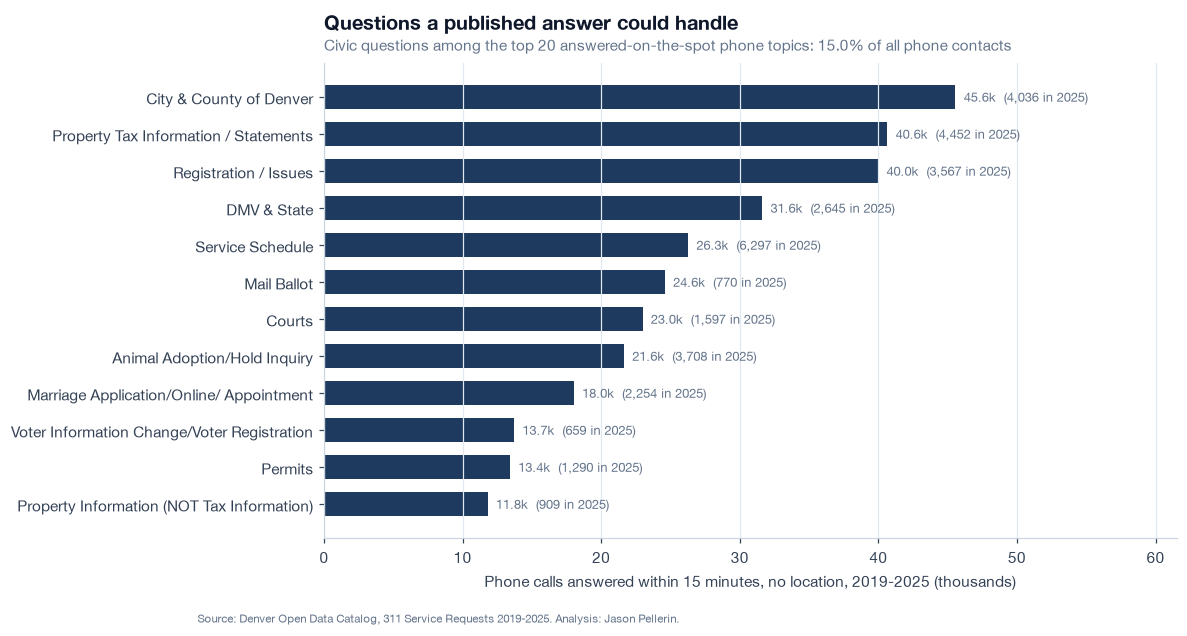

In [10]:
dc = q("SELECT * FROM agg_deflection_candidates")
answerable = dc[(dc.request_category != "Public Safety (non-emergency)") & ~dc.request_type.isin(["Other", "OOJ"])]
civic = answerable.head(12).iloc[::-1]
civic_share = answerable.share_of_all_phone_contacts.sum()
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.barh(civic.request_type, civic.answered_calls_7y / 1000, color=NAVY, height=0.65)
for i, (v, v25) in enumerate(zip(civic.answered_calls_7y, civic.answered_calls_2025)):
    ax.text(v / 1000 + 0.6, i, f"{v / 1000:.1f}k  ({v25:,} in 2025)", va="center", fontsize=8.5, color=SLATE)
ax.set_xlabel("Phone calls answered within 15 minutes, no location, 2019-2025 (thousands)")
ax.set_xlim(0, civic.answered_calls_7y.max() / 1000 * 1.35)
ax.set_title("Questions a published answer could handle", pad=22)
style.subtitle(ax, f"Civic questions among the top 20 answered-on-the-spot phone topics: {civic_share:.1%} of all phone contacts")
ax.grid(axis="y", visible=False)
style.save(fig, "fig11_deflection");
print(f"civic share of phone contacts: {civic_share:.4f}")

## Place: do some neighborhoods wait longer for the same work?

Raw medians by neighborhood mislead, because neighborhoods ask for different things. The
**wait index** ranks each closed request against every other request of the same type in the
same year (0 = fastest, 1 = slowest) and averages that rank by area. 0.50 means typical.

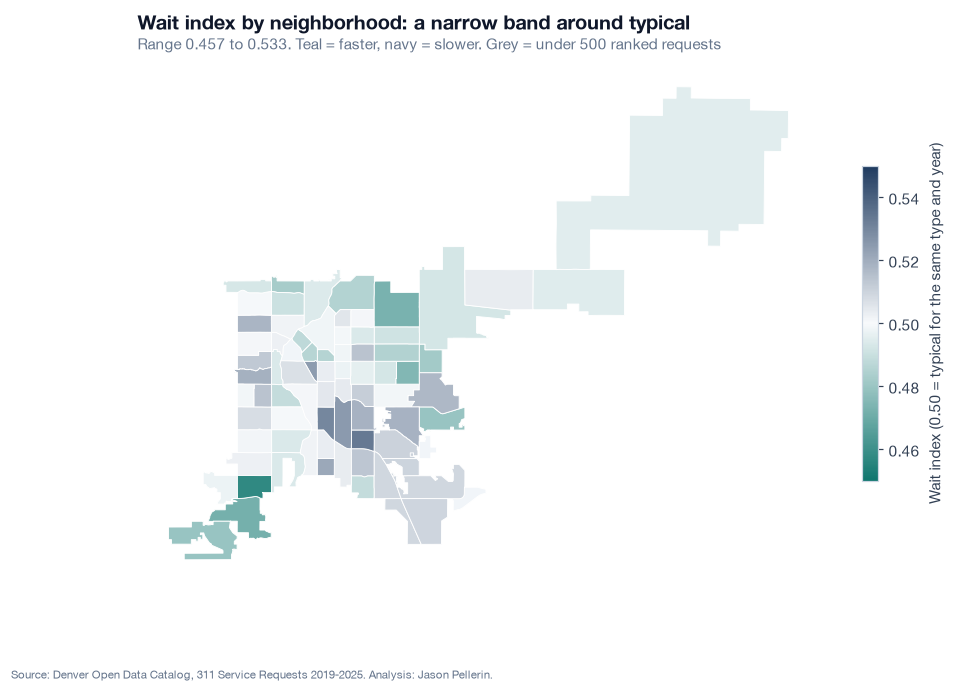

In [11]:
nb = q("SELECT * FROM agg_neighborhood")
reliable = nb[nb.ranked_requests >= 500]
values = dict(zip(reliable.nbhd_id, reliable.wait_index))
fig, ax = plt.subplots(figsize=(10, 6.2))
norm = TwoSlopeNorm(vmin=0.45, vcenter=0.5, vmax=0.55)
style.plot_neighborhoods(ax, RAW_DIR / "neighborhoods_acs_2019_2023.geojson", values, style.DIVERGING, norm)
sm = plt.cm.ScalarMappable(cmap=style.DIVERGING, norm=norm)
cb = fig.colorbar(sm, ax=ax, shrink=0.6, label="Wait index (0.50 = typical for the same type and year)")
ax.set_title("Wait index by neighborhood: a narrow band around typical", pad=22)
style.subtitle(ax, f"Range {reliable.wait_index.min():.3f} to {reliable.wait_index.max():.3f}. Teal = faster, navy = slower. Grey = under 500 ranked requests")
style.save(fig, "fig12_neighborhood_wait_map");

r(wait, income)=0.056  r(wait, poverty)=-0.048  r(demand per 1k, poverty)=0.240


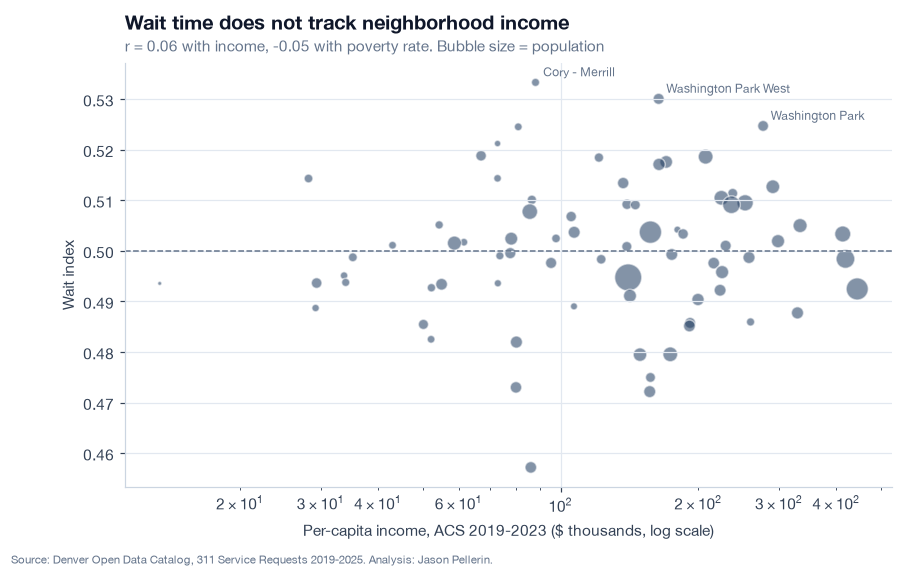

In [12]:
r_income = reliable.wait_index.corr(reliable.per_capita_income)
r_poverty = reliable.wait_index.corr(reliable.pct_poverty)
r_demand = nb.field_requests_per_1k_per_year.corr(nb.pct_poverty)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(reliable.per_capita_income / 1000, reliable.wait_index, s=reliable.population / 150, color=NAVY, alpha=0.55, edgecolor="white")
ax.axhline(0.5, color=SLATE, lw=1, ls="--")
for _, row in reliable.nlargest(3, "wait_index").iterrows():
    ax.annotate(row.neighborhood, (row.per_capita_income / 1000, row.wait_index), xytext=(5, 4), textcoords="offset points", fontsize=8, color=SLATE)
ax.set_xscale("log")
ax.set_xlabel("Per-capita income, ACS 2019-2023 ($ thousands, log scale)")
ax.set_ylabel("Wait index")
ax.set_title("Wait time does not track neighborhood income", pad=22)
style.subtitle(ax, f"r = {r_income:.2f} with income, {r_poverty:.2f} with poverty rate. Bubble size = population")
style.save(fig, "fig13_wait_vs_income");
print(f"r(wait, income)={r_income:.3f}  r(wait, poverty)={r_poverty:.3f}  r(demand per 1k, poverty)={r_demand:.3f}")

In [13]:
q("SELECT council_district, ranked_requests, round(wait_index, 3) AS wait_index, round(p50_days, 2) AS p50_days FROM agg_council_district")

,council_district,ranked_requests,wait_index,p50_days
0,1,20022,0.504,3.47
1,2,7909,0.486,2.99
2,3,12587,0.509,2.82
3,4,10397,0.510,2.66
4,5,12910,0.496,2.81
5,6,13641,0.516,3.61
6,7,20697,0.507,2.97
7,8,13665,0.489,2.03
8,9,18564,0.500,2.20
9,10,18534,0.501,2.82


Once request mix is controlled, place explains very little: every council district sits
between 0.486 and 0.516, and neighborhood wait does not move with income or poverty. Demand
does: requests per resident rise with the poverty rate (r about 0.24), so capacity planning
should run on per-resident demand, not on raw counts.

## Recommendations

1. **Close the loop before measuring speed.** Require agency systems to write status back to 311
   and publish a monthly record-integrity check (share never closed, share closed on one day).
   Code enforcement in 2023-2024 is the case study.
2. **Triage app submissions like phone calls.** App cases close later in every compared type.
   Set a same-day triage target for app intake and track the app-minus-phone median gap.
3. **Publish the answers people call for.** Civic questions answered on the spot (property tax
   statements, vehicle registration, trash schedule, ballots, courts, pet adoption) are about
   15% of phone contacts. An address-based trash-day lookup and seasonal phone messages fit
   the biggest ones.
4. **Staff to the season.** Encampment reports double in June, parks and trees peak in June,
   neighborhood inspection peaks in January (sidewalk snow), and summer brings weeds.
5. **Watch the wait index, not raw medians,** and plan capacity on requests per resident.